In [2]:
import numpy as np
import serpentine as sp
import cooler
import hicstuff.view as hcv
import hicstuff.hicstuff as hcs
import hicstuff.io as hio
import gc
from matplotlib import pyplot as plt
from matplotlib.colors import LogNorm
from cooltools.lib.numutils import coarsen
print(cooler.__version__)
print(sp.__version__)

0.9.3
0.1.3


Specify the input and output paths

In [3]:
cooldir="/mnt/e/Science/ssHiC/Contact_files/Cool/S288c/" #directory containing the cool files binned at kb
out_dir="/mnt/f/Nextcloud/DR07_UMR5239_Experiments/HiC/Serpentine/DSB/" #output directory for ratio maps


If needed, clear objects from memory

In [35]:
del cool1, cool2, dense1, dense2, nA, nB, cA, cB, sA, sB, sK
gc.collect()


23297

Load data, perform a subsampling on the whole matrix so that they contain the same number of contacts, and convert to dense format.

In [22]:
# 1) Load cooler matrices binned at 1kb in COO sparse + fragments + chroms using hicstuff
# Fragment-level cooler files must be binned at 1 kb using hicstuff rebin or cooler coarsen functions.

inputA = "AD401" #write sample name A here e.g. AP47
suffixA = "_S288c_DSB_LY_Capture_artificial_v12_cutsite_q20_v312_1kb_PCRfree"
inputB = "AD477"
suffixB = "_S288c_DSB_LY_Capture_artificial_v12_cutsite_q20_v312_1kb_PCRfree"

cool1 = str(cooldir + inputA + suffixA + ".cool")   # or "file1.cool"
cool2 = str(cooldir + inputB + suffixB + ".cool") 

mat1, frags1, chroms1 = hio.flexible_hic_loader(cool1)
mat2, frags2, chroms2 = hio.flexible_hic_loader(cool2)

# 2) Compute total contacts (sum of matrix entries)
total1 = mat1.data.sum()
total2 = mat2.data.sum()
print("Total contacts:", total1, total2)

# 3) Subsample the larger to match the smaller
if total1 > total2:
    target = total2
    mat1_sub = hcs.subsample_contacts(mat1, target)
    mat2_sub = mat2
    frags_sub = frags1   # keep frags from mat1
    out_prefix = "file1_subsampled"
else:
    target = total1
    mat2_sub = hcs.subsample_contacts(mat2, target)
    mat1_sub = mat1
    frags_sub = frags2
    out_prefix = "file2_subsampled"

print("Subsampled to", target, "contacts")

#convert matrices from COO to dense format
dense1=hcv.sparse_to_dense(mat1_sub, remove_diag=False)
dense2=hcv.sparse_to_dense(mat2_sub, remove_diag=False)


Total contacts: 49532168 13889217
Subsampled to 13889217 contacts


Isolate chr5 and subsample so that both samples have the same number of contacts per raw and columns.

557966
557966


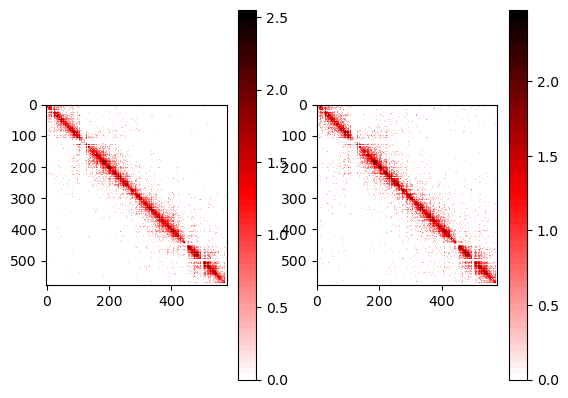

In [23]:
chrom="chr5"
start = min(frags1[(frags1["chrom"]== chrom)].index.values)
stop = max(frags1[(frags1["chrom"]== chrom)].index.values)

nA=dense1[start:stop,start:stop]
nB=dense2[start:stop,start:stop]

bins=len(sum(nA))

for i in range(0,bins):
    a=np.array(nA[:,i], dtype="int64")
    b=np.array(nB[:,i], dtype="int64")
    target = min(sum(a), sum(b))
    #print(sum(a))
    #print(sum(b))
    if sum(a)>sum(b):
        a_idx = np.array([i for i in range(len(a))])
        a_idx = np.repeat(np.arange(len(a)), a)
        a_sub_idx = np.random.permutation(a_idx)[:target]
        a_sub_idx, a_sub_vals = np.unique(a_sub_idx, return_counts=True)
        a_sub = np.zeros(a.shape)
        a_sub[a_sub_idx] = a_sub_vals
        #print(a_sub)
        #print(int(sum(a_sub)))
        nA[:,i]=a_sub
    else:
        b_idx = np.array([i for i in range(len(b))])
        b_idx = np.repeat(np.arange(len(b)), b)
        b_sub_idx = np.random.permutation(b_idx)[:target]
        b_sub_idx, b_sub_vals = np.unique(b_sub_idx, return_counts=True)
        b_sub = np.zeros(b.shape)
        b_sub[b_sub_idx] = b_sub_vals
        #print(b_sub)
        #print(int(sum(b_sub)))
        nB[:,i]=b_sub

#print(sum(sum(nA)))
#print(sum(sum(nB)))

for i in range(0,bins):
    a=np.array(nA[i,:], dtype="int64")
    b=np.array(nB[i,:], dtype="int64")
    target = min(sum(a), sum(b))
    #print(sum(a))
    #print(sum(b))
    if sum(a)>sum(b):
        a_idx = np.array([i for i in range(len(a))])
        a_idx = np.repeat(np.arange(len(a)), a)
        a_sub_idx = np.random.permutation(a_idx)[:target]
        a_sub_idx, a_sub_vals = np.unique(a_sub_idx, return_counts=True)
        a_sub = np.zeros(a.shape)
        a_sub[a_sub_idx] = a_sub_vals
        #print(a_sub)
        #print(int(sum(a_sub)))
        nA[i,:]=a_sub
    else:
        b_idx = np.array([i for i in range(len(b))])
        b_idx = np.repeat(np.arange(len(b)), b)
        b_sub_idx = np.random.permutation(b_idx)[:target]
        b_sub_idx, b_sub_vals = np.unique(b_sub_idx, return_counts=True)
        b_sub = np.zeros(b.shape)
        b_sub[b_sub_idx] = b_sub_vals
        #print(b_sub)
        #print(int(sum(b_sub)))
        nB[i,:]=b_sub
        
        
cA = np.array(nA, dtype="int64")
cB = np.array(nB, dtype="int64")

print(sum(sum(cA[:,0:bins])))
print(sum(sum(cB[:,0:bins])))

        
fig = plt.figure()
ax1 = fig.add_subplot(1, 2, 1); sp.mshow(cA, subplot=ax1)
ax2 = fig.add_subplot(1, 2, 2); sp.mshow(cB, subplot=ax2)

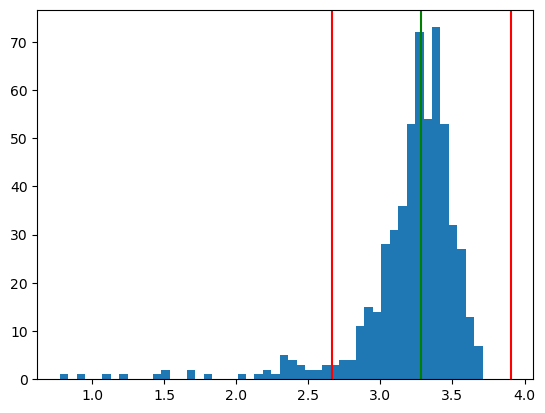

In [24]:
#The raw data needs to be filtered in order to clean the unmappable rows and columns, this kind of artifacts shows up in the distribution of reads per bin as outliers:

plt.figure()
norm = np.log10(np.sum(cA + cB, axis=0)[np.sum(cA + cB, axis=0) > 0])
norm = norm[np.isnan(norm) == False]
norm = norm[np.isinf(np.abs(norm)) == False]
plt.hist(norm, bins=50)
plt.axvline(x=np.median(norm), color='g')
plt.axvline(x=np.median(norm) - 3 * 1.4826 * sp.mad(norm), color='r')
plt.axvline(x=np.median(norm) + 3 * 1.4826 * sp.mad(norm), color='r')

Serpenting binning the data

The binning function takes two parameters: a threshold that constrains the coverage of the bin in at least one matrix, and the minthreshold that constrain it in both. The function uses multiple processors and can be configured by the optional parameters:

In [ ]:
high = 50 #default 50 or threshold
low = 10 #default 5 or threshold/5
cycles = 30

plt.figure()
trend, threshold = sp.MDbefore(cA, cB, ylim=[-4, 4])
print(trend, threshold)

from scipy.ndimage import gaussian_filter
sA, sB, sK = sp.serpentin_binning(cA, cB, high, low, cycles)

#check binning quality
plt.figure()
sp.MDafter(sA, sB, sK, ylim=[-4, 4])

fig = plt.figure();
sp.mshow(sA, subplot=ax1)
ax2 = fig.add_subplot(1, 2, 2)
sp.mshow(sB, subplot=ax2)

plt.figure()
np.warnings.filterwarnings('ignore')
D = np.log2(cB/cA)
sp.dshow(D, trend, cmap= "bwr")


-0.037766685652595285 49.999999999999986
Starting 30 binning processes in batches of 4...
0	 Total serpentines: 334084 (100.0 %)
0	 Total serpentines: 334084 (100.0 %)
0	 Total serpentines: 334084 (100.0 %)
0	 Total serpentines: 334084 (100.0 %)
1	 Total serpentines: 222357 (66.55721315597275 %)
1	 Total serpentines: 222343 (66.55302259312029 %)
1	 Total serpentines: 222440 (66.58205720716946 %)
1	 Total serpentines: 222376 (66.56290034841537 %)
2	 Total serpentines: 77071 (23.06934782868979 %)
2	 Total serpentines: 76952 (23.03372804444391 %)
2	 Total serpentines: 76771 (22.979550053280015 %)
2	 Total serpentines: 77037 (23.05917074747668 %)
3	 Total serpentines: 28494 (8.528992708420637 %)
3	 Total serpentines: 28578 (8.554136085535374 %)
3	 Total serpentines: 28531 (8.540067767387843 %)
3	 Total serpentines: 28662 (8.579279462650112 %)
4	 Total serpentines: 12729 (3.810119610636846 %)
4	 Total serpentines: 12733 (3.8113169143089762 %)
4	 Total serpentines: 12736 (3.812214892063074 %

Compute, plot and export ratio maps: B/A (top) and A/B (bottom)

AD475 over AD401_AD572
mean= -0.0021956657970814164  trend= -0.03554469974654455


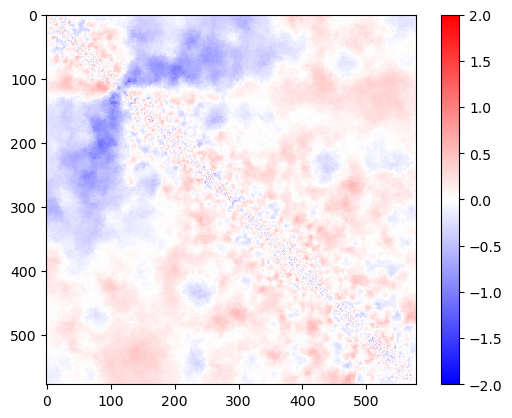

In [20]:
#Plot B over A
lim = 2          #set the +/- limit of the log2 scale. 
tr = np.mean(sK) #by default
#tr = 0
print(str(inputB), "over", str(inputA))
print("mean=", np.mean(sK), " trend=", trend)
sp.dshow(sK, tr, cmap="bwr", limit = lim)
plt.savefig(str(out_dir + inputB + "over" + inputA + "_" + chrom + "_1kb_tr_mean_" + str(tr) + "_lim_" 
                + str(lim) + "_high-low_" + str(high) + "-" + str(low) + ".pdf"), format='pdf', dpi=600)

AD401_AD572 over AD475
-0.0021956657970814164 -0.03554469974654455


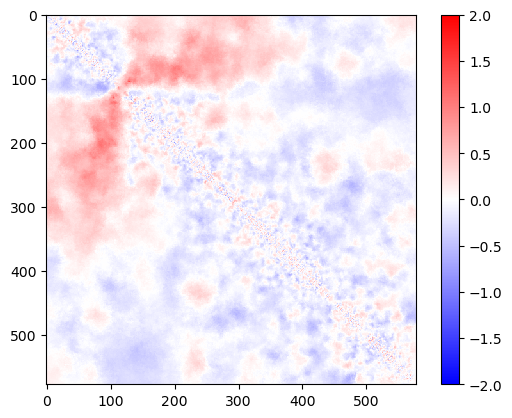

In [21]:
#Plot A over B
lim = 2
tr = np.mean(sK)
#tr=0
print(str(inputA), "over", str(inputB))
print(np.mean(sK), trend)
sp.dshow(-sK, -tr, cmap="bwr", limit = lim)
plt.savefig(str(out_dir + inputA + "over" + inputB + "_" + chrom + "_1kb_tr_mean_" + str(tr) + "_lim_"
                + str(lim) + "_high-low_" + str(high) + "-" + str(low) + ".pdf"), format='pdf', dpi=600)